# 🛠️ SPRINT 2: Pré-Processamento e Feature Engineering

**Equipe:** Grupo 05

## SEÇÃO 1: REVISÃO DOS ACHADOS E CARREGAMENTO
Nesta secção, iniciamos a fase de preparação de dados recapitulando os principais problemas identificados na base de dados durante a Análise Exploratória (EDA) da Sprint 1, e carregamos os dados brutos para iniciar o tratamento.

### ⚠️ Principais Desafios Mapeados na Sprint 1:
1. **Outliers Severos:** Identificámos que a nossa variável alvo (`price_usd`) possui ruídos significativos, incluindo jogos gratuitos ($0.00) e títulos premium extremos (>$100.00), que distorcem a média.
2. **Valores Ausentes (Missing Values):** Colunas cruciais, em especial o `metacritic_score`, possuem lacunas que necessitam de estratégias de imputação ou remoção.
3. **Complexidade Categórica (Encoding):** O *dataset* possui variáveis em formato de texto (Géneros, Publicadoras, Categorias) que precisam de ser transformadas em representações numéricas para serem legíveis pelo algoritmo de *Machine Learning*.

In [1]:
import pandas as pd
import numpy as np

# Configuração para exibir todas as colunas no VS Code/Colab
pd.set_option('display.max_columns', None)

print("--- 1. CARREGAMENTO DOS DADOS BRUTOS ---")

# Link RAW do vosso repositório no GitHub (garantindo a reprodutibilidade)
url_github = 'https://raw.githubusercontent.com/JoaoDysarz/steam-price-prediction/main/data/Sprint_01/steam_top_games_2026.csv'

# Carregando o dataset original (bruto)
df_raw = pd.read_csv(url_github)

print(f"✅ Dataset bruto carregado com sucesso!")
print(f"➜ Total de Linhas (Jogos): {df_raw.shape[0]}")
print(f"➜ Total de Colunas (Features): {df_raw.shape[1]}\n")

# Fazemos uma cópia de segurança para o processamento, mantendo o df_raw intacto
df_processado = df_raw.copy()

# Exibindo as primeiras linhas
df_processado.head()

--- 1. CARREGAMENTO DOS DADOS BRUTOS ---
✅ Dataset bruto carregado com sucesso!
➜ Total de Linhas (Jogos): 1495
➜ Total de Colunas (Features): 29



,app_id,name,release_date,coming_soon,price_usd,is_free,discount_pct,developer,publisher,genres,categories,tags,platforms_win,platforms_mac,platforms_linux,metacritic_score,recommendations,positive_reviews,negative_reviews,estimated_owners,avg_playtime_forever,avg_playtime_2weeks,median_playtime,peak_ccu,required_age,dlc_count,achievements,short_description,header_image
0,794260,Outward Definitive Edition,"May 17, 2022",False,4.79,False,88,Nine Dots Studio,"Prime Matter, Deep Silver",RPG,"Single-player, Multi-player, Co-op, Online Co-...","RPG, Open World, Survival, Co-op, Online Co-Op...",True,False,False,NaN,23986,20738,7717,"1,000,000 .. 2,000,000",1332,824,465,469,0,1,72,No remarkable journey is achieved without grea...,https://shared.akamai.steamstatic.com/store_it...
1,253920,Gorky 17,"Sep 27, 2013",False,9.99,False,0,Metropolis Software,TopWare Interactive,"RPG, Strategy","Single-player, Steam Trading Cards, Family Sha...","RPG, Strategy, Turn-Based, Classic, Horror, Po...",True,True,True,NaN,909,1616,411,"200,000 .. 500,000",301,0,328,61,17,2,0,November 2008. NATO intelligence services repo...,https://shared.akamai.steamstatic.com/store_it...
2,613010,Secret in Story,"Jun 19, 2017",False,0.89,False,10,Naivus Luo,Naivus Luo,"Adventure, Indie","Single-player, Steam Achievements, Steam Tradi...","Indie, Adventure, Visual Novel",True,True,False,NaN,0,79,35,"2,000,000 .. 5,000,000",251,0,243,0,0,0,32,"Accompanied by beautiful piano music, you begi...",https://shared.akamai.steamstatic.com/store_it...
3,892420,懒人修仙传,"Nov 14, 2018",False,3.99,False,0,托更的修罗,托更的修罗,"Casual, Indie, RPG, Simulation","Single-player, Family Sharing","Simulation, Casual, RPG, Indie, Word Game, Idler",True,False,False,NaN,1169,769,509,"200,000 .. 500,000",5786,0,9223,41,0,0,0,这是一款很&quot;休闲&quot;的文字挂机游戏，游戏小而系统完善，玩法丰富，极其耗电，...,https://shared.akamai.steamstatic.com/store_it...
4,914010,Train Station Renovation,"Oct 1, 2020",False,18.99,False,0,Live Motion Games,"Live Motion Games, Frozen Way, PlayWay S.A., F...","Casual, Indie, Simulation","Single-player, Steam Achievements, Steam Cloud...","Simulation, Casual, Indie, Trains, First-Perso...",True,False,False,68.0,1948,2154,466,"200,000 .. 500,000",448,0,201,16,0,1,73,"Welcome to an old, ruined train station. A pla...",https://shared.akamai.steamstatic.com/store_it...


## SEÇÃO 2: TRATAMENTO DE DADOS NULOS

**Objetivo:** Garantir que o dataset não possui valores em branco (NaN) que façam o algoritmo de *Machine Learning* quebrar, aplicando estratégias adequadas para cada tipo de variável.

### 📋 Decisões de Negócio e Justificações:
1. **Remoção de Variáveis Irrelevantes:** As colunas `app_id` (identificador aleatório), `name` (texto livre) e `header_image` (URL de imagem) não possuem qualquer poder preditivo matemático. Mantê-las apenas aumentaria o custo computacional. Serão removidas.
2. **Nulos Residuais (Linhas):** Variáveis categóricas importantes como `genres`, `developer` e `publisher` possuem menos de 1% de dados nulos. A exclusão destas poucas linhas (`.dropna()`) é a decisão mais segura, pois não compromete o volume estatístico da base.
3. **A Estratégia do Metacritic (Imputação adiada):** A coluna `metacritic_score` apresenta ~57% de dados nulos. 
    * *Porquê não excluir a coluna?* Porque provámos na Sprint 1 (Hipótese 2) que ela é uma excelente preditora para jogos caros.
    * *Porquê não imputar (preencher) agora?* Para seguir as boas práticas e evitar o **Vazamento de Dados (Data Leakage)**. A imputação dos valores vazios será feita utilizando a **Mediana** (para não ser distorcida por *outliers*), mas apenas **dentro do Pipeline do Scikit-Learn**, após a separação de Treino e Teste.

In [2]:
print("--- 2. TRATAMENTO DE NULOS E LIMPEZA INICIAL ---")

# 1. Remoção de colunas que não agregam valor preditivo
colunas_para_remover = ['app_id', 'name', 'header_image', 'short_description']

# Adicionamos tags, categories e estimated_owners pois têm cardinalidade extrema ou formatos sujos
colunas_para_remover.extend(['tags', 'categories', 'estimated_owners', 'release_date_formatada'])

# Removendo do df_processado (verificando se existem antes de dar drop)
colunas_alvo = [col for col in colunas_para_remover if col in df_processado.columns]
df_processado = df_processado.drop(columns=colunas_alvo)

print(f"Colunas removidas com sucesso: {colunas_alvo}\\n")

# 2. Remoção de linhas com nulos nas variáveis categóricas (Nulos Residuais)
# Vamos listar as colunas textuais essenciais
colunas_categoricas = ['genres', 'publisher', 'developer', 'release_date']

antes_drop = len(df_processado)
df_processado = df_processado.dropna(subset=colunas_categoricas)
depois_drop = len(df_processado)

print(f"Linhas removidas devido a nulos residuais: {antes_drop - depois_drop}")
print(f"Tamanho atual do Dataset: {depois_drop} linhas.\\n")

# 3. Auditoria final de nulos
print("--- AUDITORIA DE NULOS ATUAL ---")
nulos_restantes = df_processado.isnull().sum()
nulos_restantes = nulos_restantes[nulos_restantes > 0]
print(nulos_restantes)
print("\\n✅ Nota: É esperado e proposital que o 'metacritic_score' e 'release_year' ainda tenham nulos aqui. Serão tratados via Pipeline e Feature Engineering.")

--- 2. TRATAMENTO DE NULOS E LIMPEZA INICIAL ---
Colunas removidas com sucesso: ['app_id', 'name', 'header_image', 'short_description', 'tags', 'categories', 'estimated_owners']\n
Linhas removidas devido a nulos residuais: 30
Tamanho atual do Dataset: 1465 linhas.\n
--- AUDITORIA DE NULOS ATUAL ---
metacritic_score    936
dtype: int64
\n✅ Nota: É esperado e proposital que o 'metacritic_score' e 'release_year' ainda tenham nulos aqui. Serão tratados via Pipeline e Feature Engineering.


## SEÇÃO 3: TRATAMENTO DE OUTLIERS

**Objetivo:** Limpar os valores extremos da nossa variável alvo (`price_usd`) que podem confundir o modelo de Regressão Linear.

### Decisões:
1. **O problema dos jogos gratuitos:** Um jogo custar $0.00 não é um erro de digitação, é um modelo de negócio diferente (Free-to-Play). Só que misturar jogos grátis com jogos pagos bagunça totalmente a média de preços. Como o nosso objetivo é prever o "preço de prateleira", vamos remover todos os jogos com preço igual a zero.
2. **O problema dos preços absurdos:** Pelo Boxplot da Sprint 1, vimos que jogos acima de USD 60.00 são casos raros (edições super premium ou pacotes). Vamos usar a técnica estatística do Limite Superior do IQR (Intervalo Interquartil) para cortar de forma matemática esses pontos fora da curva, evitando que eles puxem a reta do nosso modelo para cima.

--- 3. TRATAMENTO DE OUTLIERS NO PREÇO ---
Jogos gratuitos removidos: 0
Jogos muito caros (acima de USD 42.49) removidos: 0
Tamanho do dataset após a limpeza: 1047 linhas.



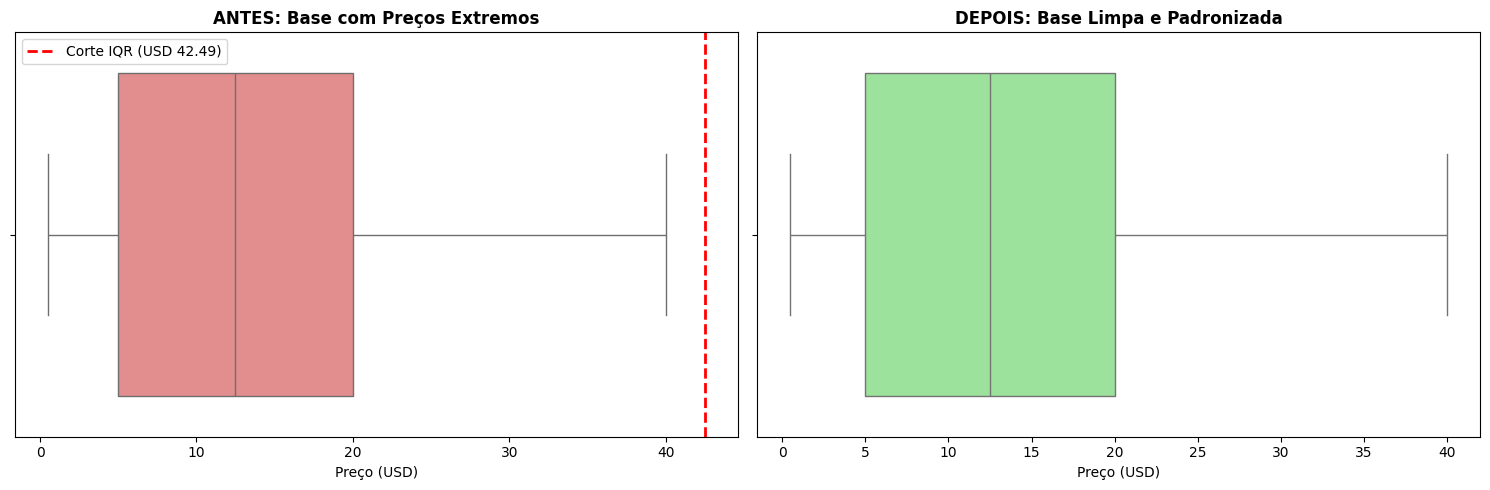

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 3. TRATAMENTO DE OUTLIERS NO PREÇO ---")

tamanho_antes = len(df_processado)

# 1. Removendo os jogos gratuitos (Free-to-Play)
df_processado = df_processado[df_processado['price_usd'] > 0]
jogos_pagos = len(df_processado)
print(f"Jogos gratuitos removidos: {tamanho_antes - jogos_pagos}")

# 2. Calculando o Limite Superior (IQR)
Q1 = df_processado['price_usd'].quantile(0.25)
Q3 = df_processado['price_usd'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

# Separando os dados limpos para atualizar nosso dataset
df_limpo = df_processado[df_processado['price_usd'] <= limite_superior]
depois_outliers = len(df_limpo)

print(f"Jogos muito caros (acima de USD {limite_superior:.2f}) removidos: {jogos_pagos - depois_outliers}")
print(f"Tamanho do dataset após a limpeza: {depois_outliers} linhas.\n")

# ==========================================
# 3. VISUALIZAÇÃO: ANTES VS DEPOIS
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: ANTES (Mostrando a sujeira e a linha de corte)
sns.boxplot(data=df_processado, x='price_usd', color='lightcoral', ax=axes[0])
axes[0].set_title('ANTES: Base com Preços Extremos', fontweight='bold')
axes[0].set_xlabel('Preço (USD)')
axes[0].axvline(limite_superior, color='red', linestyle='--', linewidth=2, label=f'Corte IQR (USD {limite_superior:.2f})')
axes[0].legend()

# Gráfico 2: DEPOIS (Base limpa e comportada)
sns.boxplot(data=df_limpo, x='price_usd', color='lightgreen', ax=axes[1])
axes[1].set_title('DEPOIS: Base Limpa e Padronizada', fontweight='bold')
axes[1].set_xlabel('Preço (USD)')

plt.tight_layout()
plt.show()

# Atualizando o dataset oficial de processamento
df_processado = df_limpo

## SEÇÃO 4: ENGENHARIA DE VARIÁVEIS (FEATURE ENGINEERING)

**Objetivo:** Criar novas características (features) que ajudem o modelo a entender o contexto do negócio e a prever o preço com mais precisão.

### Variáveis Criadas e Justificações:
1. `publishing_model`: Separa os jogos entre "Self-Published" (indies puros) e "Publisher-Backed" (jogos com investimento de uma editora). Como vimos na Sprint 1, ter uma empresa financiando o projeto muda completamente o patamar de preço do jogo.
2. `genre_count`: Conta quantos géneros estão associados ao jogo. A lógica é que jogos que misturam muitos géneros (ex: Estratégia + RPG + Simulação) costumam ser projetos mais complexos e ambiciosos, o que justifica um preço mais alto.
3. `release_year`: Extrai apenas o ano da coluna de data de lançamento. Isso ajuda o modelo a capturar a tendência de aumento de preços na Steam ao longo dos anos (inflação dos jogos).

In [5]:
print("--- 4. CRIANDO NOVAS VARIÁVEIS (FEATURE ENGINEERING) ---")

# 1. Criando o Modelo de Publicação (Self-Published vs Publisher-Backed)
df_processado['publishing_model'] = np.where(
    df_processado['developer'] == df_processado['publisher'], 
    'Self-Published', 
    'Publisher-Backed'
)

# 2. Contando a quantidade de géneros (separados por ponto e vírgula no dataset)
df_processado['genre_count'] = df_processado['genres'].apply(
    lambda x: len(str(x).split(';')) if pd.notnull(x) else 1
)

# 3. Extraindo o Ano de Lançamento da data de texto
df_processado['release_year'] = pd.to_datetime(df_processado['release_date'], errors='coerce').dt.year

# Se algum formato de data falhar, preenchemos com o ano mais comum (moda) para não gerar nulos
ano_moda = df_processado['release_year'].mode()[0]
df_processado['release_year'] = df_processado['release_year'].fillna(ano_moda).astype(int)

print("✅ Novas colunas criadas com sucesso!")
print(f"➜ Total de colunas agora: {df_processado.shape[1]}")

# Mostrando uma amostra das colunas novas que criámos
df_processado[['developer', 'publisher', 'publishing_model', 'genre_count', 'release_year']].head()

--- 4. CRIANDO NOVAS VARIÁVEIS (FEATURE ENGINEERING) ---
✅ Novas colunas criadas com sucesso!
➜ Total de colunas agora: 25


,developer,publisher,publishing_model,genre_count,release_year
0,Nine Dots Studio,"Prime Matter, Deep Silver",Publisher-Backed,1,2022
1,Metropolis Software,TopWare Interactive,Publisher-Backed,1,2018
2,Naivus Luo,Naivus Luo,Self-Published,1,2018
3,托更的修罗,托更的修罗,Self-Published,1,2018
4,Live Motion Games,"Live Motion Games, Frozen Way, PlayWay S.A., F...",Publisher-Backed,1,2018


## SEÇÃO 5: SELEÇÃO DE FEATURES E SEPARAÇÃO (TRAIN/TEST SPLIT)

**Objetivo:** Escolher apenas as colunas que vão alimentar o modelo e separar a base para evitar o Vazamento de Dados (*Data Leakage*).

### Decisões:
1. **Seleção (Feature Selection):** Vamos deixar fora as colunas textuais originais (`genres`, `developer`, `publisher`, `release_date`). *Porquê?* Porque elas têm alta cardinalidade (milhares de nomes diferentes) e isso iria explodir o nosso modelo criando milhares de colunas inúteis. Nós já extraímos a "inteligência" delas na Secção 4 através das variáveis `genre_count`, `publishing_model` e `release_year`.
2. **Separação Antes da Transformação:** Seguindo as melhores práticas, dividimos o dataset em 80% para Treino e 20% para Teste **antes** de aplicar qualquer cálculo de média ou escala.

---

## SEÇÃO 6: PIPELINE DO SCIKIT-LEARN (ENCODING E SCALING)

**Objetivo:** Criar uma "fábrica" automatizada que limpa e transforma os dados na mesma sequência, tanto para o treino como para dados futuros.

### Decisões e Justificações:
1. **Tratamento do Metacritic (Imputação):** Avaliámos usar o `KNNImputer`, mas optámos pelo `SimpleImputer` com a **Mediana**. A mediana é resistente a notas extremas e consome menos processamento computacional.
2. **StandardScaler:** Aplicamos nas variáveis numéricas para colocar o `genre_count`, `release_year` e `metacritic_score` na mesma escala (média 0, desvio padrão 1), evitando que o ano (ex: 2023) tenha um peso matematicamente superior à nota do Metacritic (ex: 85).
3. **OneHotEncoder:** Transforma a nossa coluna de texto `publishing_model` ("Self-Published" / "Publisher-Backed") em colunas binárias (0 e 1) de forma limpa.

--- 5. SELEÇÃO E SEPARAÇÃO DE DADOS ---
Dados de Treino: 837 linhas
Dados de Teste: 210 linhas

--- 6. CONSTRUÇÃO DO PIPELINE SCIKIT-LEARN ---
✅ Pipeline construído e aplicado com sucesso!

--- AUDITORIA VISUAL: PROVA DE CONCEITO ---


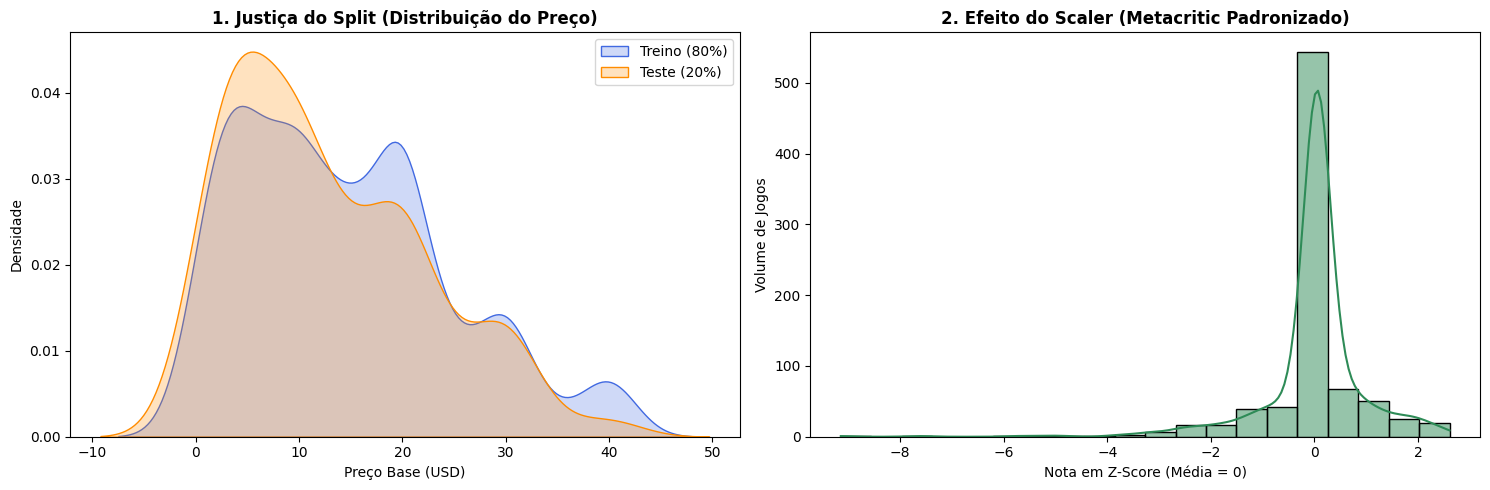

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 5. SELEÇÃO E SEPARAÇÃO DE DADOS ---")

# Deitando fora o texto original que já foi transformado na Secção 4
colunas_drop = ['genres', 'developer', 'publisher', 'release_date']
df_modelagem = df_processado.drop(columns=colunas_drop)

# Separando X (Previsores) e y (Alvo)
X = df_modelagem.drop(columns=['price_usd'])
y = df_modelagem['price_usd']

# Train/Test Split (80% Treino, 20% Teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dados de Treino: {X_train.shape[0]} linhas")
print(f"Dados de Teste: {X_test.shape[0]} linhas\n")


print("--- 6. CONSTRUÇÃO DO PIPELINE SCIKIT-LEARN ---")

# Definindo quem é número e quem é texto
features_numericas = ['metacritic_score', 'genre_count', 'release_year']
features_categoricas = ['publishing_model']

# Pipeline numérico: Imputar Mediana -> Escalar
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline categórico: Imputar -> Transformar em 0 e 1
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Juntando tudo num único Processador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, features_numericas),
        ('cat', categorical_transformer, features_categoricas)
    ])

# 1. Fit e Transform apenas no Treino
X_train_processado = preprocessor.fit_transform(X_train)

# 2. Apenas Transform no Teste (Evitando Data Leakage)
X_test_processado = preprocessor.transform(X_test)

print("✅ Pipeline construído e aplicado com sucesso!\n")

# ==========================================
# 7. VISUALIZAÇÃO: AUDITORIA DO PIPELINE
# ==========================================
print("--- AUDITORIA VISUAL: PROVA DE CONCEITO ---")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Integridade do Split (Curvas de Densidade)
sns.kdeplot(y_train, label='Treino (80%)', fill=True, color='royalblue', ax=axes[0])
sns.kdeplot(y_test, label='Teste (20%)', fill=True, color='darkorange', ax=axes[0])
axes[0].set_title('1. (Distribuição do Preço)', fontweight='bold')
axes[0].set_xlabel('Preço Base (USD)')
axes[0].set_ylabel('Densidade')
axes[0].legend()

# Gráfico 2: Comprovando o Efeito do Scaler
# A coluna 0 no array processado é o 'metacritic_score'. 
# O StandardScaler deve colocar a média em 0 (centrado).
sns.histplot(X_train_processado[:, 0], kde=True, color='seagreen', bins=20, ax=axes[1])
axes[1].set_title('2. Efeito do Scaler (Metacritic Padronizado)', fontweight='bold')
axes[1].set_xlabel('Nota em Z-Score (Média = 0)')
axes[1].set_ylabel('Volume de Jogos')

plt.tight_layout()
plt.show()